# Customer Churn Prediction — EDA

This notebook covers the initial exploratory data analysis (EDA) 
for the customer churn dataset. The goal is to understand the 
structure, quality, and distributions of the data before any 
modeling.

In [1]:
#Libraries

import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
#Load data
DATA_PATH = Path("..") / "data" / "raw" / "customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\raw\\customer_churn.csv'

## 1. Data Loading

The dataset contains **100,000 customers** and **32 features**, 
including behavioral, financial, and support-related variables. 
The target variable is `churn` (1 = churned, 0 = retained).

In [ ]:
#General information

print("First 5 rows\n\n")
print(df.head())

First 5 rows


   customer_id  gender  age     country      city customer_segment  \
0  CUST_000001    Male   68  Bangladesh    London              SME   
1  CUST_000002  Female   57      Canada    Sydney       Individual   
2  CUST_000003    Male   24     Germany  New York              SME   
3  CUST_000004    Male   49   Australia     Dhaka       Individual   
4  CUST_000005    Male   65  Bangladesh     Delhi       Individual   

   tenure_months signup_channel contract_type  monthly_logins  ...  \
0             22            Web       Monthly              26  ...   
1              9         Mobile       Monthly               7  ...   
2             58            Web        Yearly              19  ...   
3             19         Mobile        Yearly              34  ...   
4             52            Web       Monthly              20  ...   

   avg_resolution_time  complaint_type  csat_score  escalations  \
0            13.354360         Service         4.0            0   
1        

In [ ]:
print("Basic information\n\n")
print(df.info())

Basic information


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   customer_id             100000 non-null  object 
 1   gender                  100000 non-null  object 
 2   age                     100000 non-null  int64  
 3   country                 100000 non-null  object 
 4   city                    100000 non-null  object 
 5   customer_segment        100000 non-null  object 
 6   tenure_months           100000 non-null  int64  
 7   signup_channel          100000 non-null  object 
 8   contract_type           100000 non-null  object 
 9   monthly_logins          100000 non-null  int64  
 10  weekly_active_days      100000 non-null  int64  
 11  avg_session_time        100000 non-null  float64
 12  features_used           100000 non-null  int64  
 13  usage_growth_rate       100000 non-null  float64
 14  l

In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        print(f"{col}: {df[col].nunique()} únicos → {df[col].unique()}")

customer_id: 100000 únicos → ['CUST_000001' 'CUST_000002' 'CUST_000003' ... 'CUST_099998' 'CUST_099999'
 'CUST_100000']
gender: 2 únicos → ['Male' 'Female']
country: 7 únicos → ['Bangladesh' 'Canada' 'Germany' 'Australia' 'India' 'USA' 'UK']
city: 7 únicos → ['London' 'Sydney' 'New York' 'Dhaka' 'Delhi' 'Toronto' 'Berlin']
customer_segment: 3 únicos → ['SME' 'Individual' 'Enterprise']
signup_channel: 3 únicos → ['Web' 'Mobile' 'Referral']
contract_type: 3 únicos → ['Monthly' 'Yearly' 'Quarterly']
payment_method: 3 únicos → ['PayPal' 'Card' 'Bank Transfer']
discount_applied: 2 únicos → ['Yes' 'No']
price_increase_last_3m: 2 únicos → ['No' 'Yes']
complaint_type: 3 únicos → ['Service' 'Billing' 'Technical' nan]
survey_response: 3 únicos → ['Satisfied' 'Neutral' 'Unsatisfied']


## 2. First Inspection

The dataset has **32 columns** split across three data types:
- **14 integer columns** — logins, tickets, tenure, churn target
- **6 float columns** — session time, rates, scores
- **12 object columns** — categorical variables like gender, country, contract type


In [ ]:
#Missing values

missing=df.isnull().sum()
missing_percentage=(missing/len(df)*100).round(2)

missing_df=pd.DataFrame({
    "missing_count":missing,
    "missing _percentage":missing_percentage
})

missing_df=missing_df[missing_df["missing_count"]>0]

print("Columns with missing values")
print(missing_df)

Columns with missing values
                missing_count  missing _percentage
complaint_type          20534                20.53


In [ ]:
# Investigating complaint_type nulls 
mask_null = df["complaint_type"].isnull()

print("Clients WITH complaint_type null:")
print(df[mask_null]["support_tickets"].describe())

print("\nClients WITHOUT complaint_type nulL:")
print(df[~mask_null]["support_tickets"].describe())

Clients WITH complaint_type null:
count    20534.000000
mean         1.197234
std          1.094769
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: support_tickets, dtype: float64

Clients WITHOUT complaint_type nulL:
count    79466.000000
mean         1.210568
std          1.104982
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: support_tickets, dtype: float64


## 3. Missing Values

Only one column has missing values: `complaint_type` with **20,534 nulls (20.53%)**.

Investigation shows that customers with null `complaint_type` have a 
similar ticket volume (mean: 1.20) to those without nulls (mean: 1.21). 
This suggests the nulls represent **unclassified complaints**, not 
absence of complaints.

These nulls will be treated as a separate category `"Unknown"` during 
the data cleaning phase.

In [ ]:
# Churn Distribution 
churn_counts = df["churn"].value_counts()
churn_percentage = df["churn"].value_counts(normalize=True).mul(100).round(2)

churn_summary = pd.DataFrame({
    "count": churn_counts,
    "percentage": churn_percentage
})

churn_summary.index = ["Retained (0)", "Churned (1)"]

print("Churn Distribution")
print(churn_summary)

Churn Distribution
              count  percentage
Retained (0)  89863       89.86
Churned (1)   10137       10.14


## 4. Churn Distribution

The dataset is heavily imbalanced:
- **Retained (0): 89,863 customers — 89.86%**
- **Churned (1): 10,137 customers — 10.14%**

This is a critical finding. A naive model that always predicts 
"retained" would achieve ~90% accuracy but zero business value.

This imbalance will be addressed during modeling using techniques 
such as SMOTE or `class_weight` adjustments.

In [ ]:
# Descriptive Statistics 
desc = df.describe().T

descriptive_stats = df.describe().T

descriptive_stats = descriptive_stats[["mean", "std", "min", "50%", "max"]]

descriptive_stats.columns = ["mean", "std_dev", "min", "median", "max"] #Colums been renamed

descriptive_stats = descriptive_stats.round(2)

print("Descriptive Statistics")
print(descriptive_stats)

Descriptive Statistics
                         mean  std_dev     min  median      max
age                     45.83    16.40   18.00   45.00    74.00
tenure_months           30.15    17.08    1.00   30.00    59.00
monthly_logins          19.65     9.83    0.00   20.00    54.00
weekly_active_days       3.48     2.30    0.00    3.00     7.00
avg_session_time        15.20     6.84    1.00   15.18    42.00
features_used            4.97     2.21    1.00    5.00    15.00
usage_growth_rate        0.02     0.15   -0.58    0.02     0.54
last_login_days_ago      9.50     9.75    0.00    7.00    80.00
monthly_fee             35.04    23.83   10.00   30.00   100.00
total_revenue         1054.10  1018.85   10.00  720.00  5900.00
payment_failures         0.50     0.71    0.00    0.00     5.00
support_tickets          1.21     1.10    0.00    1.00     7.00
avg_resolution_time     23.99     9.97    1.00   24.02    61.82
csat_score               3.49     0.98    1.00    4.00     5.00
escalations      

## 5. Descriptive Statistics

Key observations:
- `days_since_last_login`: max of 80 days suggests disengaged customers
- `payment_failures`: some customers have up to 5 failed payments
- `usage_growth_rate`: negative values indicate declining engagement
- `total_revenue`: high std_dev (1018) reveals very diverse customer value

## 2. Visualizations

Visual exploration of the key variables and their relationship with churn.

In [ ]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
COLORS = ["#216FEE", "#F27D39"]

# 10k rows is enough to see patterns without killing performance
# random_state=42 makes the sample reproducible
df_sample = df.sample(n=10_000, random_state=42)

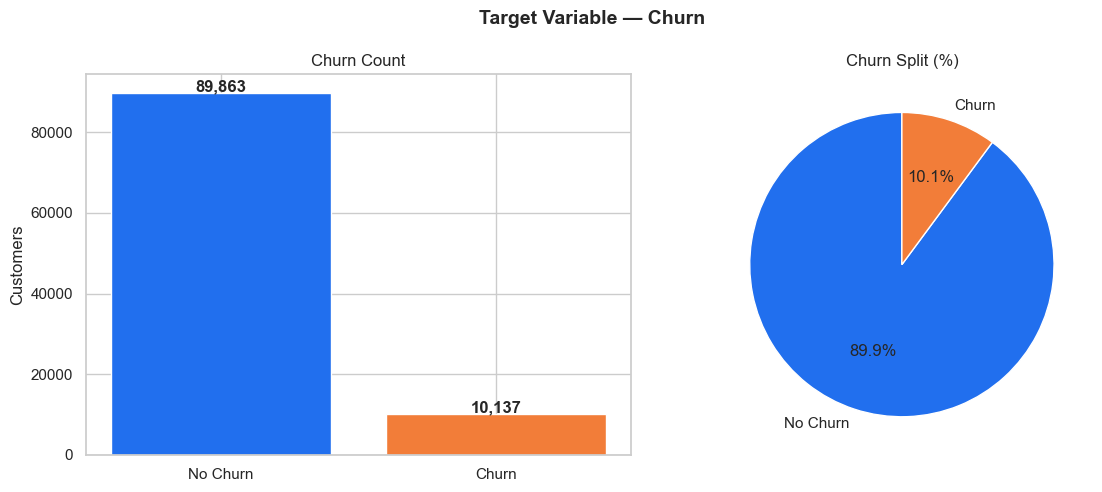

In [ ]:
# Chart 1: Target distribution
# Shows whether the classes are balanced. Imbalanced targets (e.g. 95/5 split)

churn_counts = df["churn"].value_counts()  # use full df, not sample

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["No Churn", "Churn"], churn_counts.values, color=COLORS)
axes[0].set_title("Churn Count")
axes[0].set_ylabel("Customers")

for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    colors=COLORS,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Churn Split (%)")

plt.suptitle("Target Variable — Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

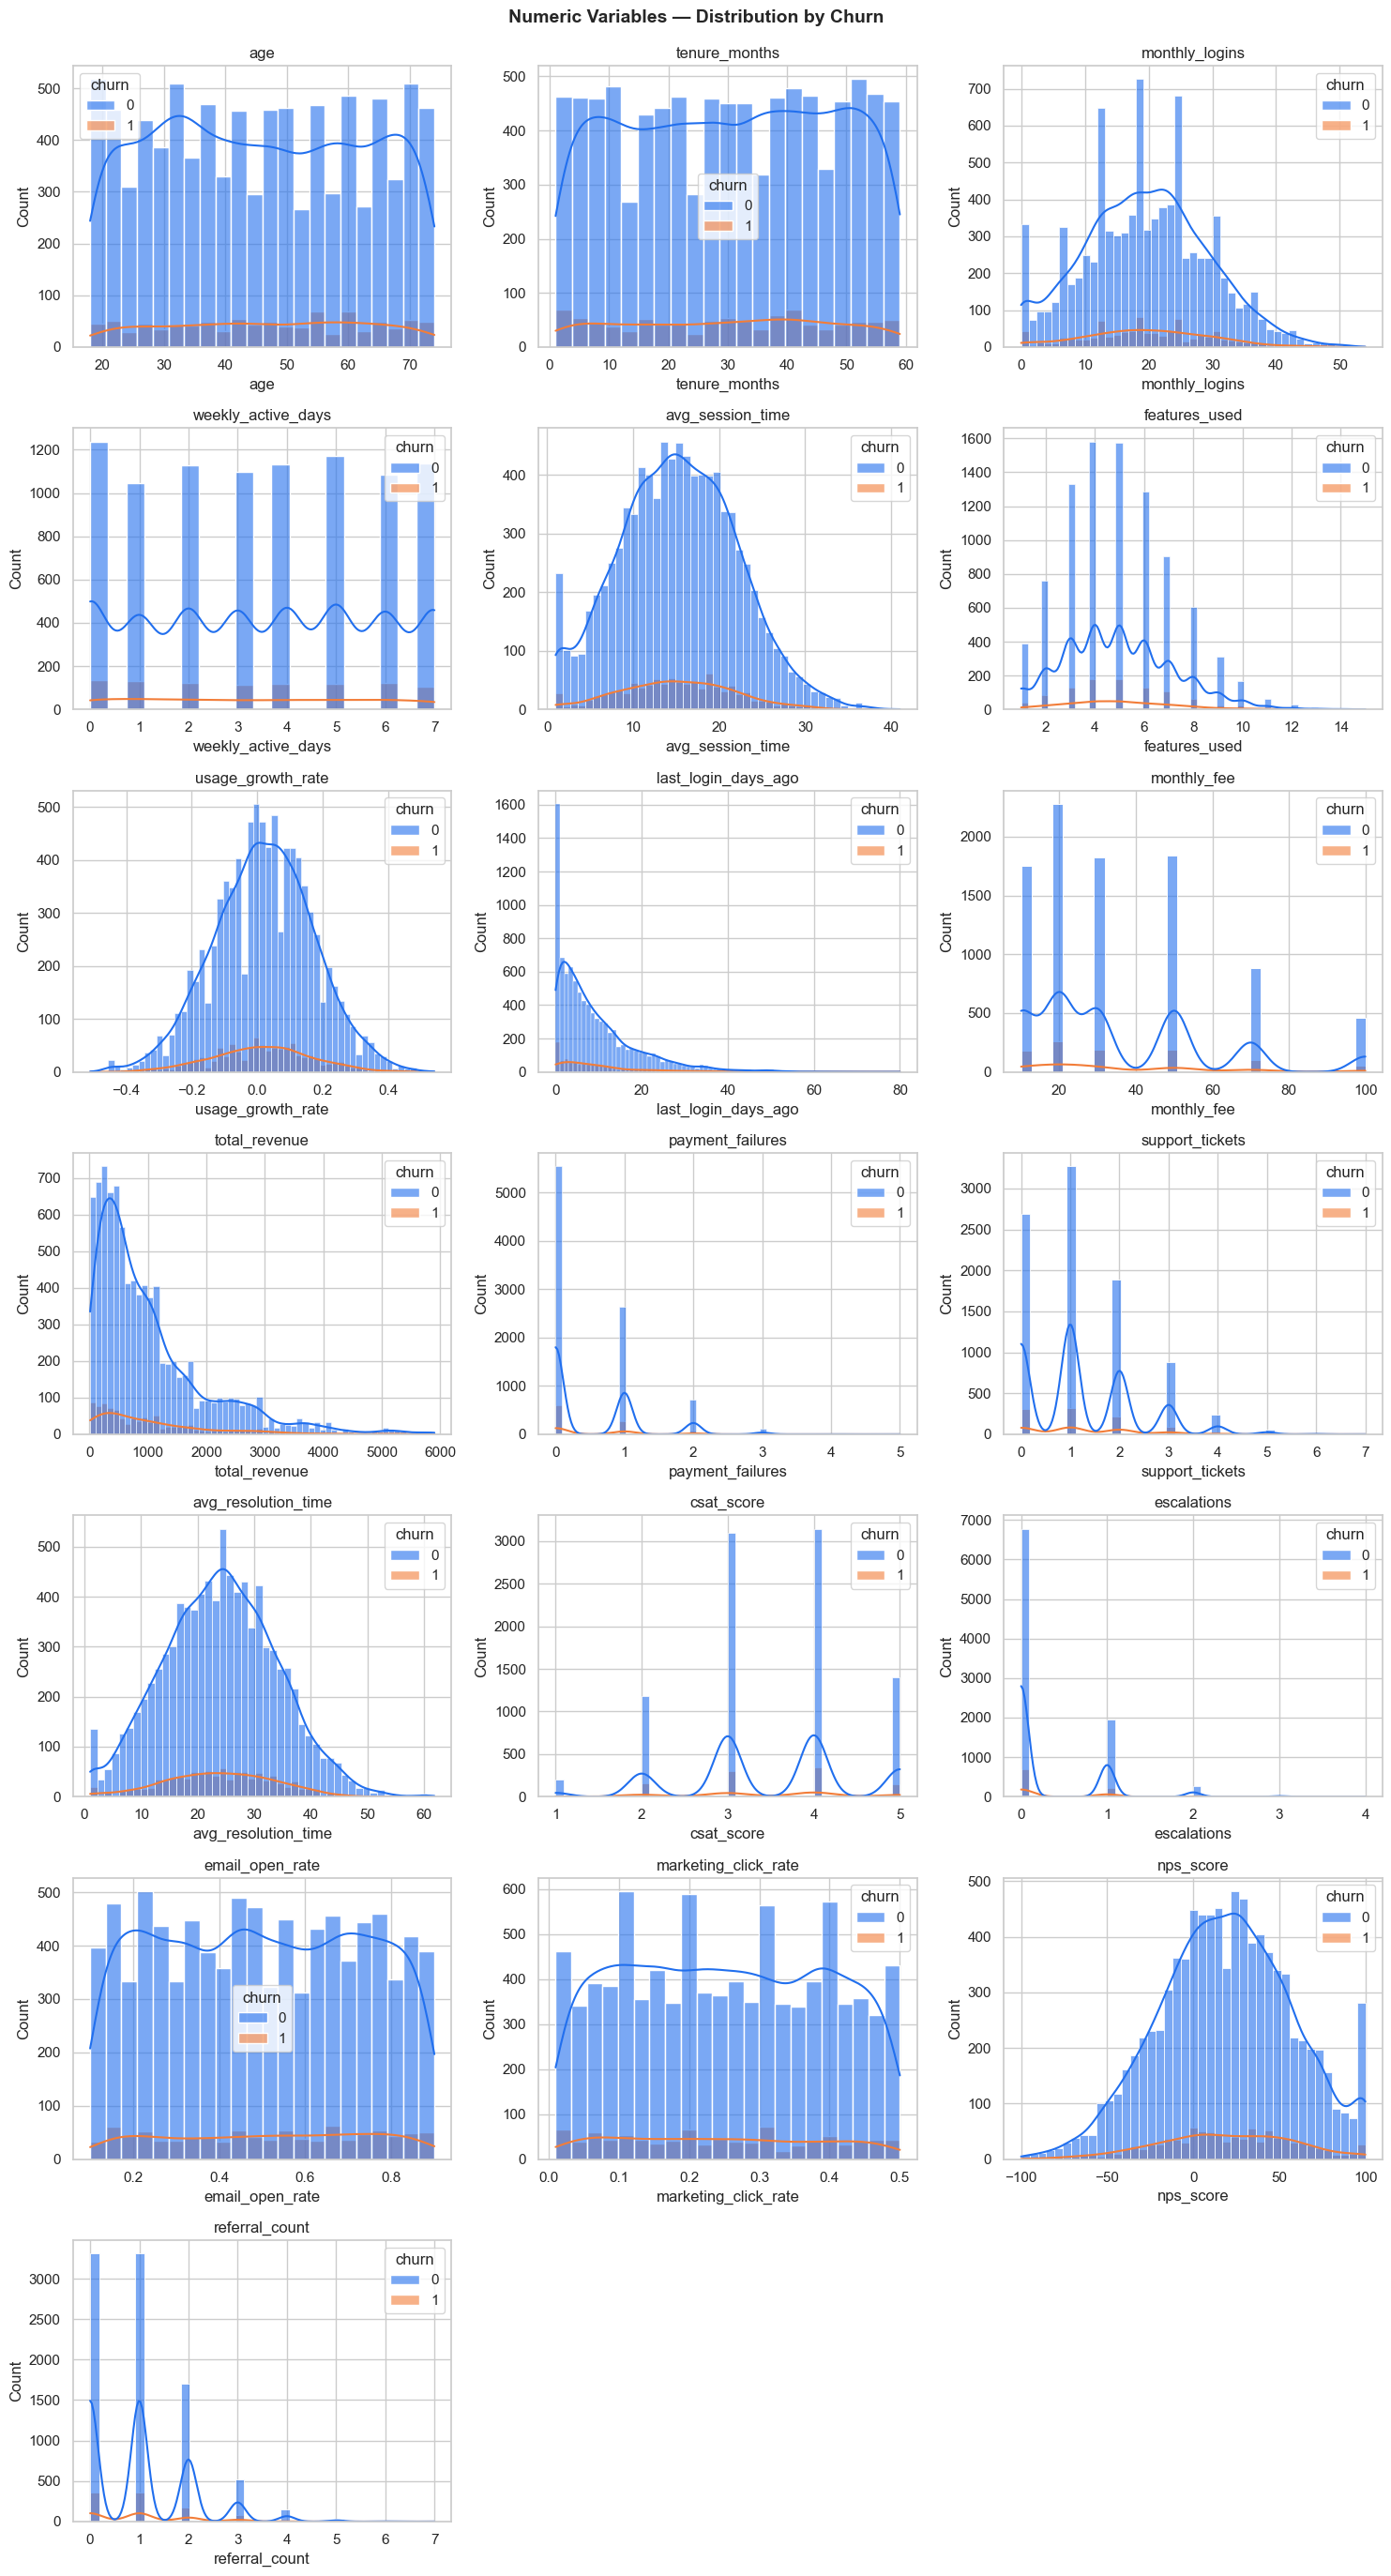

In [ ]:
# Chart 2: Numeric variable distributions 
# Overlapping KDE curves per variable, split by churn label.
# If the two curves look different, that variable is probably useful for the model.

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if "churn" in numeric_cols:
    numeric_cols.remove("churn")

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df_sample, # sample here for speed
        x=col,
        hue="churn",
        kde=True,
        palette=COLORS,
        ax=axes[i],
        alpha=0.6
    )
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Variables — Distribution by Churn\n\n", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

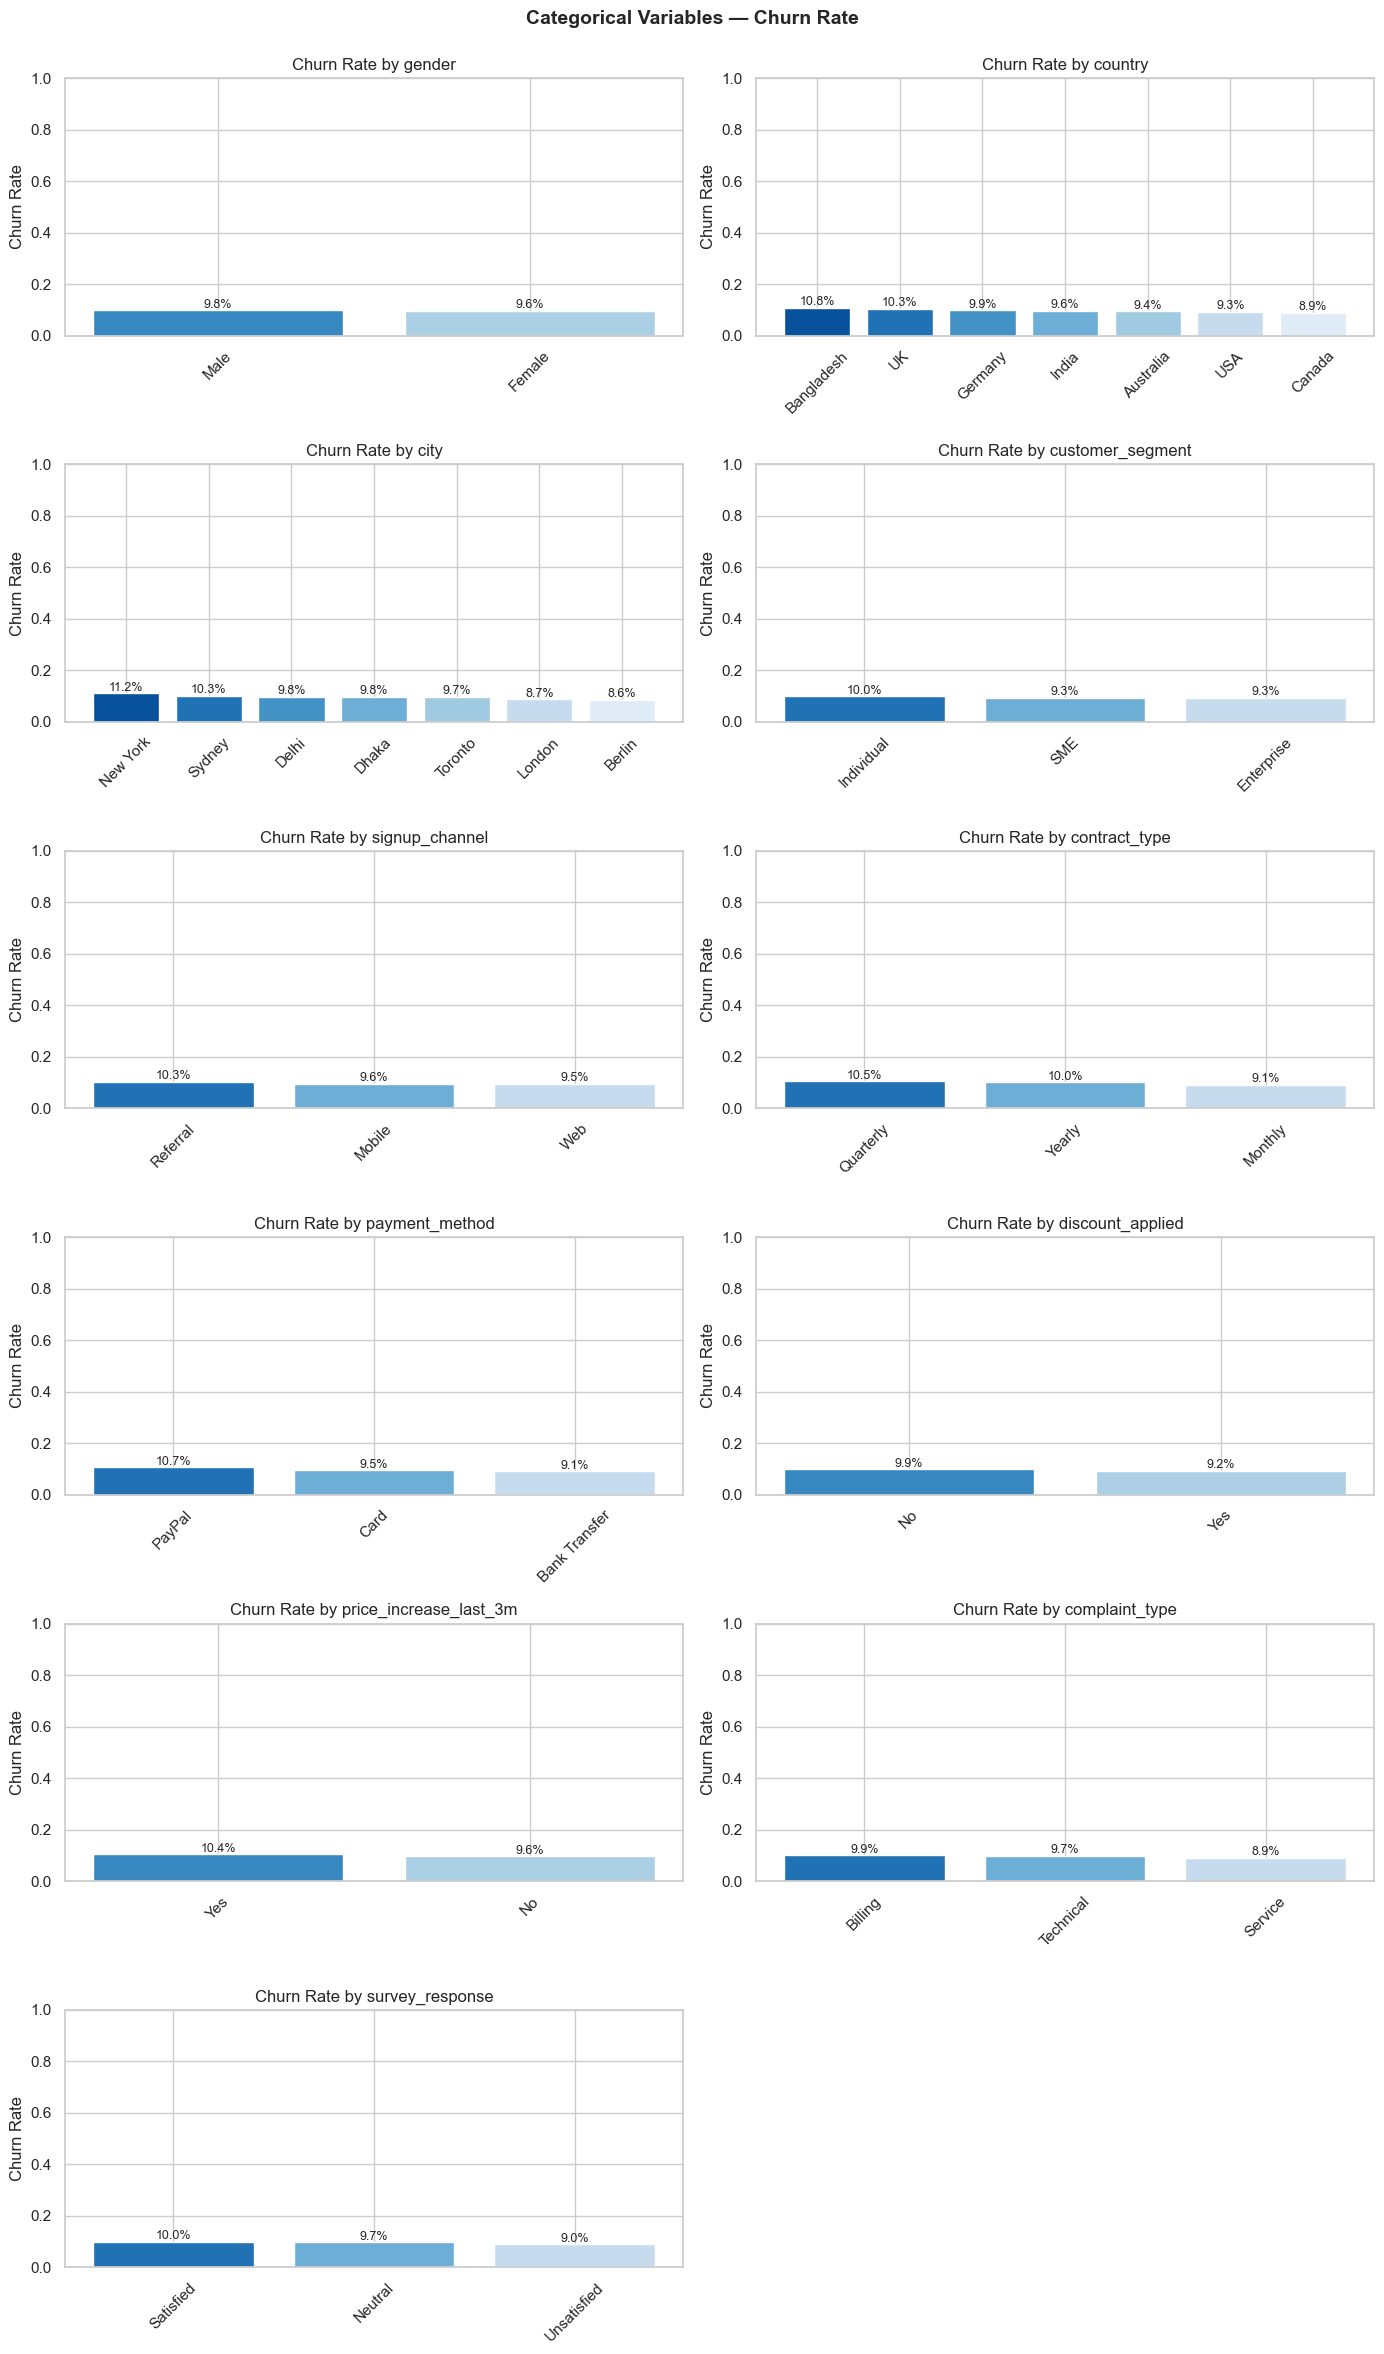

In [ ]:
# Chart 3: Churn rate by categorical variable 
# For each category, shows what % of customers churned.
# High bars = high-risk segments worth flagging to the business.

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# customer_id is a unique identifier, not a feature — drop before analysis
categorical_cols = [col for col in categorical_cols if col != "customer_id"]

n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df_sample.groupby(col)["churn"].mean().sort_values(ascending=False)

    bars = axes[i].bar(
        churn_rate.index,
        churn_rate.values,
        color=sns.color_palette("Blues_r", len(churn_rate))
    )
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=45)

    for bar in bars:
        h = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2.,
            h + 0.01,
            f"{h:.1%}",
            ha="center", fontsize=9
        )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Variables — Churn Rate\n\n", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

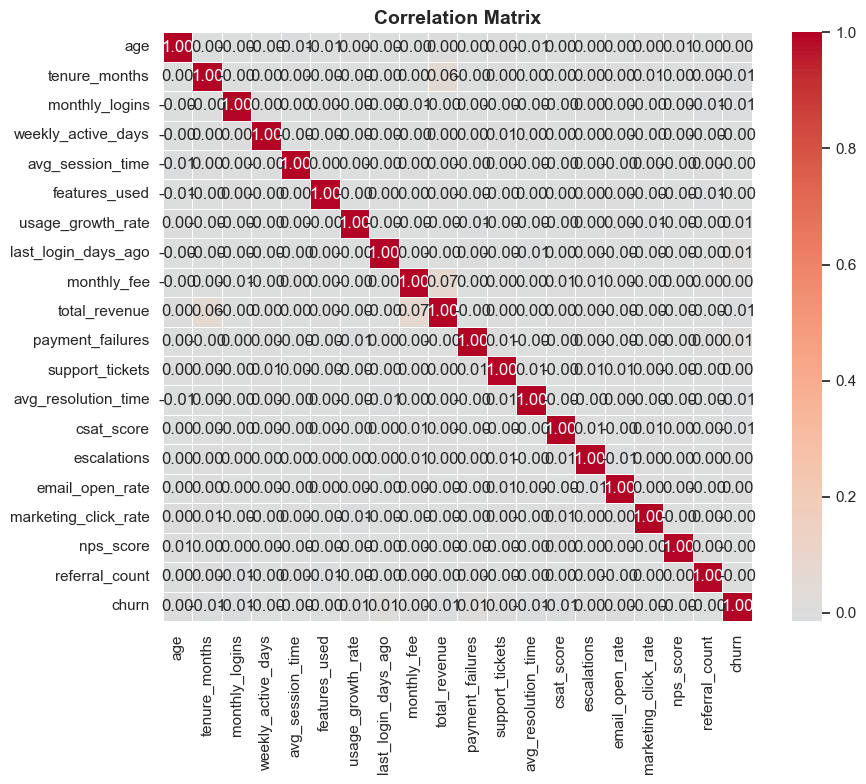

In [ ]:
# Chart 4: Correlation heatmap 
# Red = positive correlation, blue = negative. Focus on the "churn" row/column
# to see which numeric features move with the target.
# Also check for pairs with correlation > 0.9 — those might be redundant.

corr_cols = numeric_cols + ["churn"]
corr_matrix = df[corr_cols].corr()  # full df — no need to sample for this

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\sanlo\AppData\Local\Temp\ipykernel_25752\523564412.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


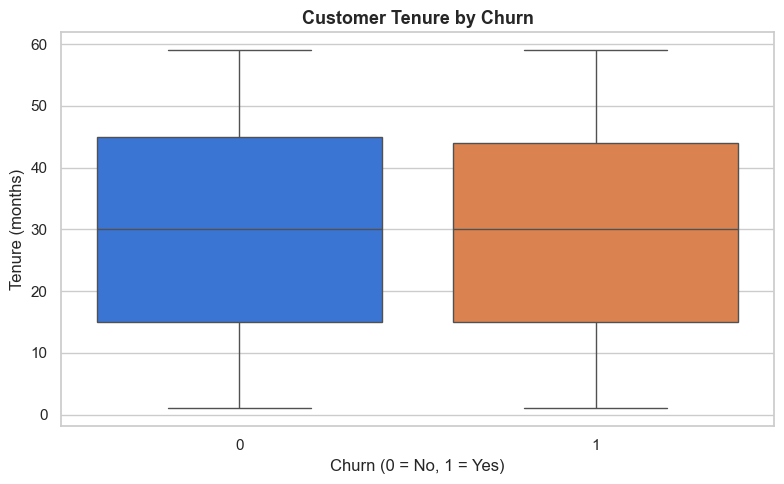

In [ ]:
# Chart 5: Customer tenure distribution by churn
# Longer-tenured customers tend to churn less — this checks that assumption.

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_sample,
    x="churn",
    y="tenure_months",
    palette=COLORS,
    ax=ax
)

ax.set_title("Customer Tenure by Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Churn (0 = No, 1 = Yes)")
ax.set_ylabel("Tenure (months)")

plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis (EDA)

### Chart 1 — Target Distribution
The dataset contains 89,863 customers who did not churn and 10,137 who did,
representing a 90/10 split. This class imbalance means a model that always
predicts "no churn" would reach 90% accuracy while being completely useless.
This needs to be handled before modeling (e.g., class_weight="balanced" or SMOTE).

### Chart 2 — Numeric Variable Distributions
All numeric distributions overlap heavily between churn and non-churn groups.
No single variable cleanly separates the two classes. avg_session_time shows
a slight concentration at lower values for churned customers, which makes
business sense — less engaged users are more likely to leave.

### Chart 3 — Churn Rate by Categorical Variable
Churn rates across all categories range from 8.9% to 11.2%, essentially flat.
No single segment stands out as significantly higher risk. customer_id was
removed from this analysis — it is a unique row identifier, not a feature.

### Chart 4 — Correlation Matrix
No numeric variable shows meaningful correlation with churn. No variable pair
shows high inter-correlation either, meaning there are no redundant features
to remove at this stage.

### Chart 5 — Customer Tenure vs Churn
The tenure distribution is nearly identical between churned and retained
customers (median ~30 months in both groups). Contrary to what real-world
data typically shows, tenure does not predict churn in this dataset.

### Key Takeaways
- **Class imbalance** (90/10) must be addressed before training any model.
- **No strong predictors** found among individual features — neither numeric
  nor categorical variables show clear separation between churn groups.
- **No multicollinearity** detected. All features can be kept at this stage.
- **Dataset is synthetic**, which explains the absence of strong feature signals.
  Feature engineering may be required to extract more predictive power.